# Introducción a la programación científica.

## Primer ejemplo

Dado el sistema 
$$-\frac{d C_A(t)}{dt} =- \frac{d C_B(t)}{dt} =  \frac{d C_C(t)}{dt} = 0.5\cdot  C_A(t)^{1/2} C_B(t)^{1/3}$$

Uno puede graficarlo usando la librería scipy.

In [2]:
import scipy as sp # para calculos cientificos
import numpy as np # para calculos numericos
import matplotlib.pyplot as plt # para graficos
import pandas as pd # para manejo de datos

El siguiente bloque lo pueden ignorar debido a que es para hacer un gráfico en la presentación.

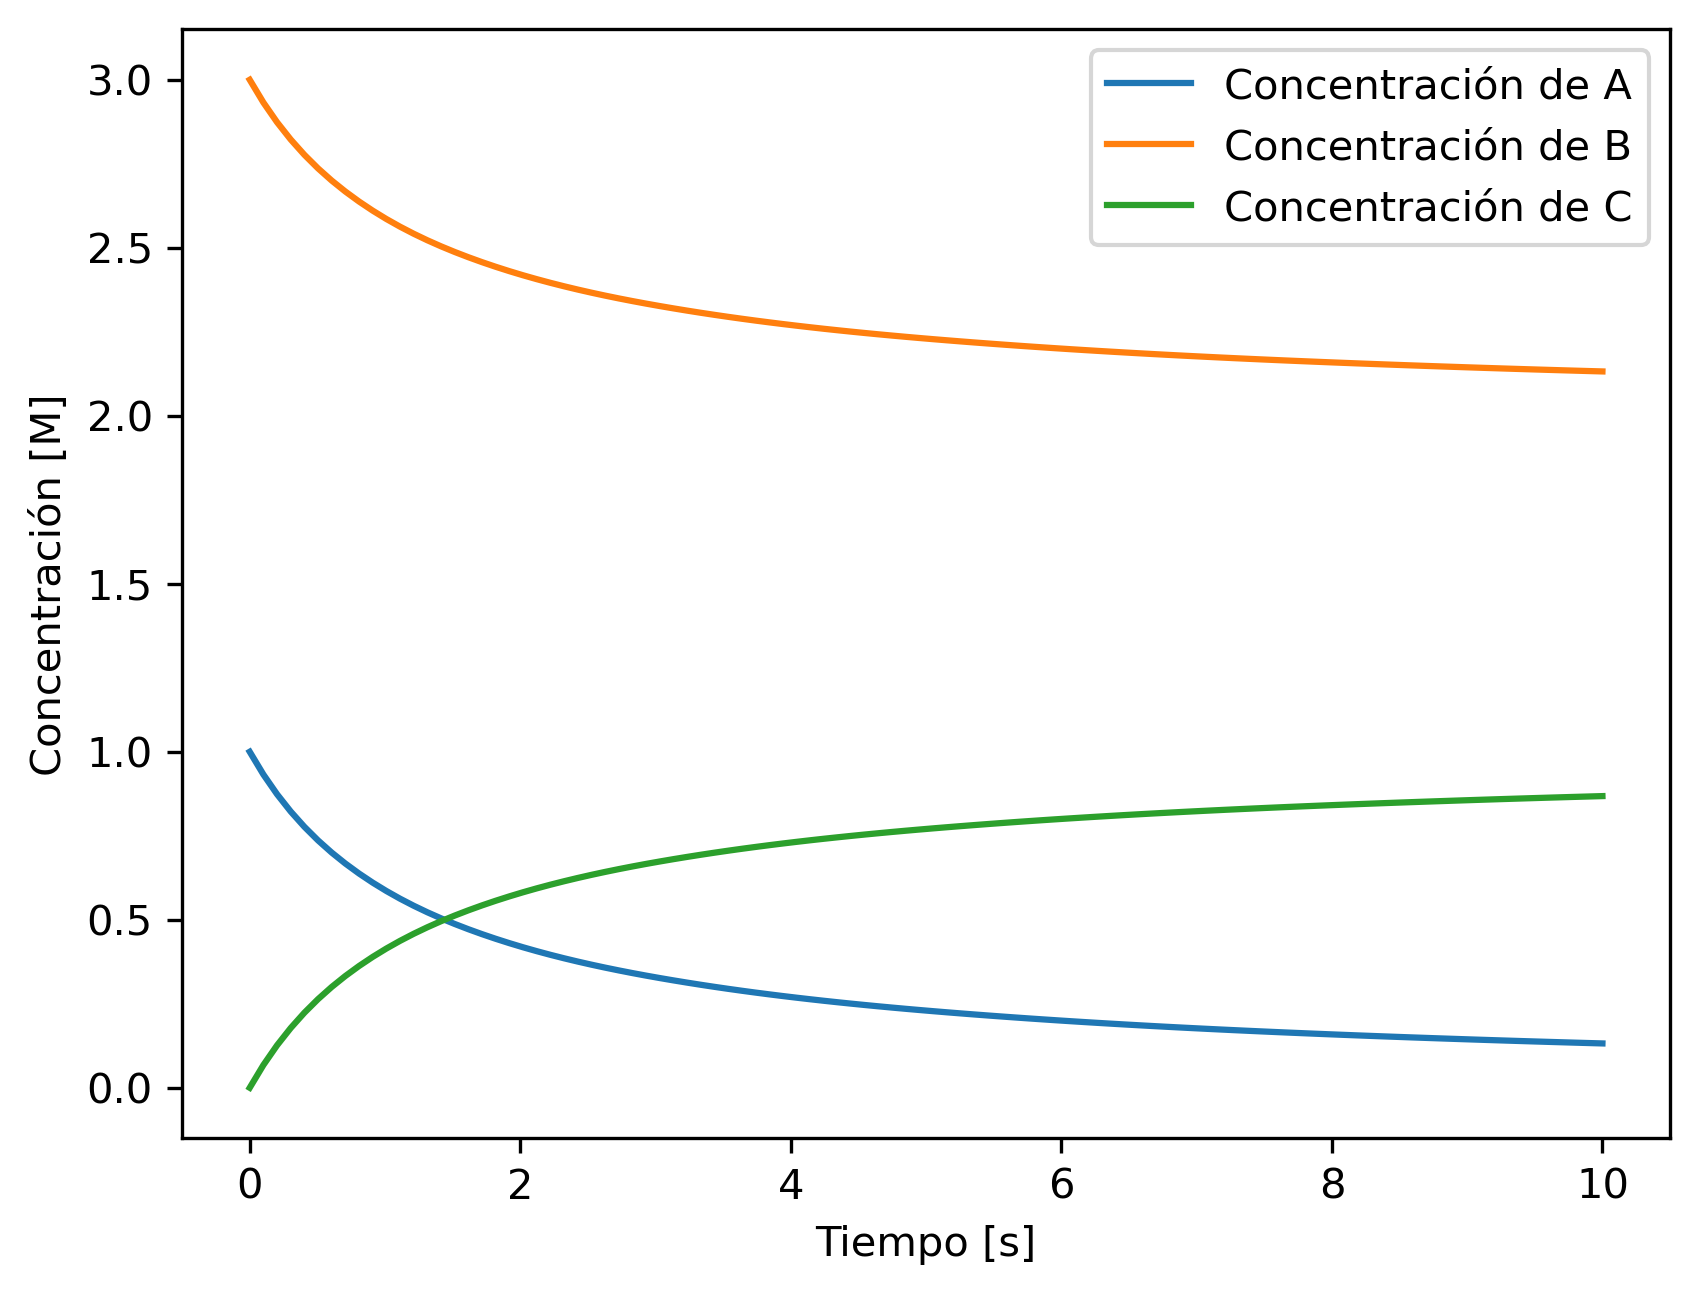

In [3]:
def ode_system(t, c):
    '''
    Sistema de ecuaciones del tipo
    dca/dt = - 0.5 ca^1/2 cb^1/3
    dcb/dt = - 0.5 ca^1/2 cb^1/3
    dcc/dt = 0.5 ca^1/2 cb^1/3
    '''
    ca, cb, cc = c
    dca_dt = - 0.5 * ca**(2) * cb**(1/3)
    dcb_dt = - 0.5 * ca**(2) * cb**(1/3)
    dcc_dt = 0.5 * ca**(2) * cb**(1/3)
    return [dca_dt, dcb_dt, dcc_dt]

# Condiciones iniciales
ca0 = 1.0 # Concentracion inicial de A
cb0 = 3.0 # Concentracion inicial de B
cc0 = 0.0 # Concentracion inicial de C
initial_conditions = [ca0, cb0, cc0]
# Intervalo de tiempo para la simulacion
t_span = (0, 10) # de 0 a 10 unidades de tiempo 
t_eval = np.linspace(t_span[0], t_span[1], 100) # 100 puntos de evaluacion
# Resolver el sistema de ecuaciones diferenciales
solution = sp.integrate.solve_ivp(ode_system, t_span, initial_conditions, t_eval=t_eval)
# Extraer las soluciones
t = solution.t
ca = solution.y[0]
cb = solution.y[1]
cc = solution.y[2]
# Graficar los resultados
fig, ax = plt.subplots(dpi = 300)
ax.plot(t, ca, label='Concentración de A')
ax.plot(t, cb, label='Concentración de B')
ax.plot(t, cc, label='Concentración de C')
ax.set_xlabel('Tiempo [s]')
ax.set_ylabel('Concentración [M]')
ax.legend()
plt.show()
    
df = pd.DataFrame({'t': t, 'ca': ca, 'cb': cb, 'cc': cc})
df.to_csv('data_plots/cinetica.csv', index=False) 
    

## Ejemplo de decaimiento 



$$
\frac{dN(t)}{dt} = - \lambda N(t); N(0) = 100
$$

In [12]:
## funcion
# paso 1
def edo(t, N, lam):
    dN_dt = - lam * N
    return dN_dt

# paso 2
t_span = [0, 5] # limites de integracion
N0 = [100] # valor inicial
t_eval = np.linspace(0, 5, 100) # 100 puntos equiespaciados
lam = 1

# paso 3
sol = sp.integrate.solve_ivp(edo, t_span, N0, t_eval=t_eval, args=(lam,),)

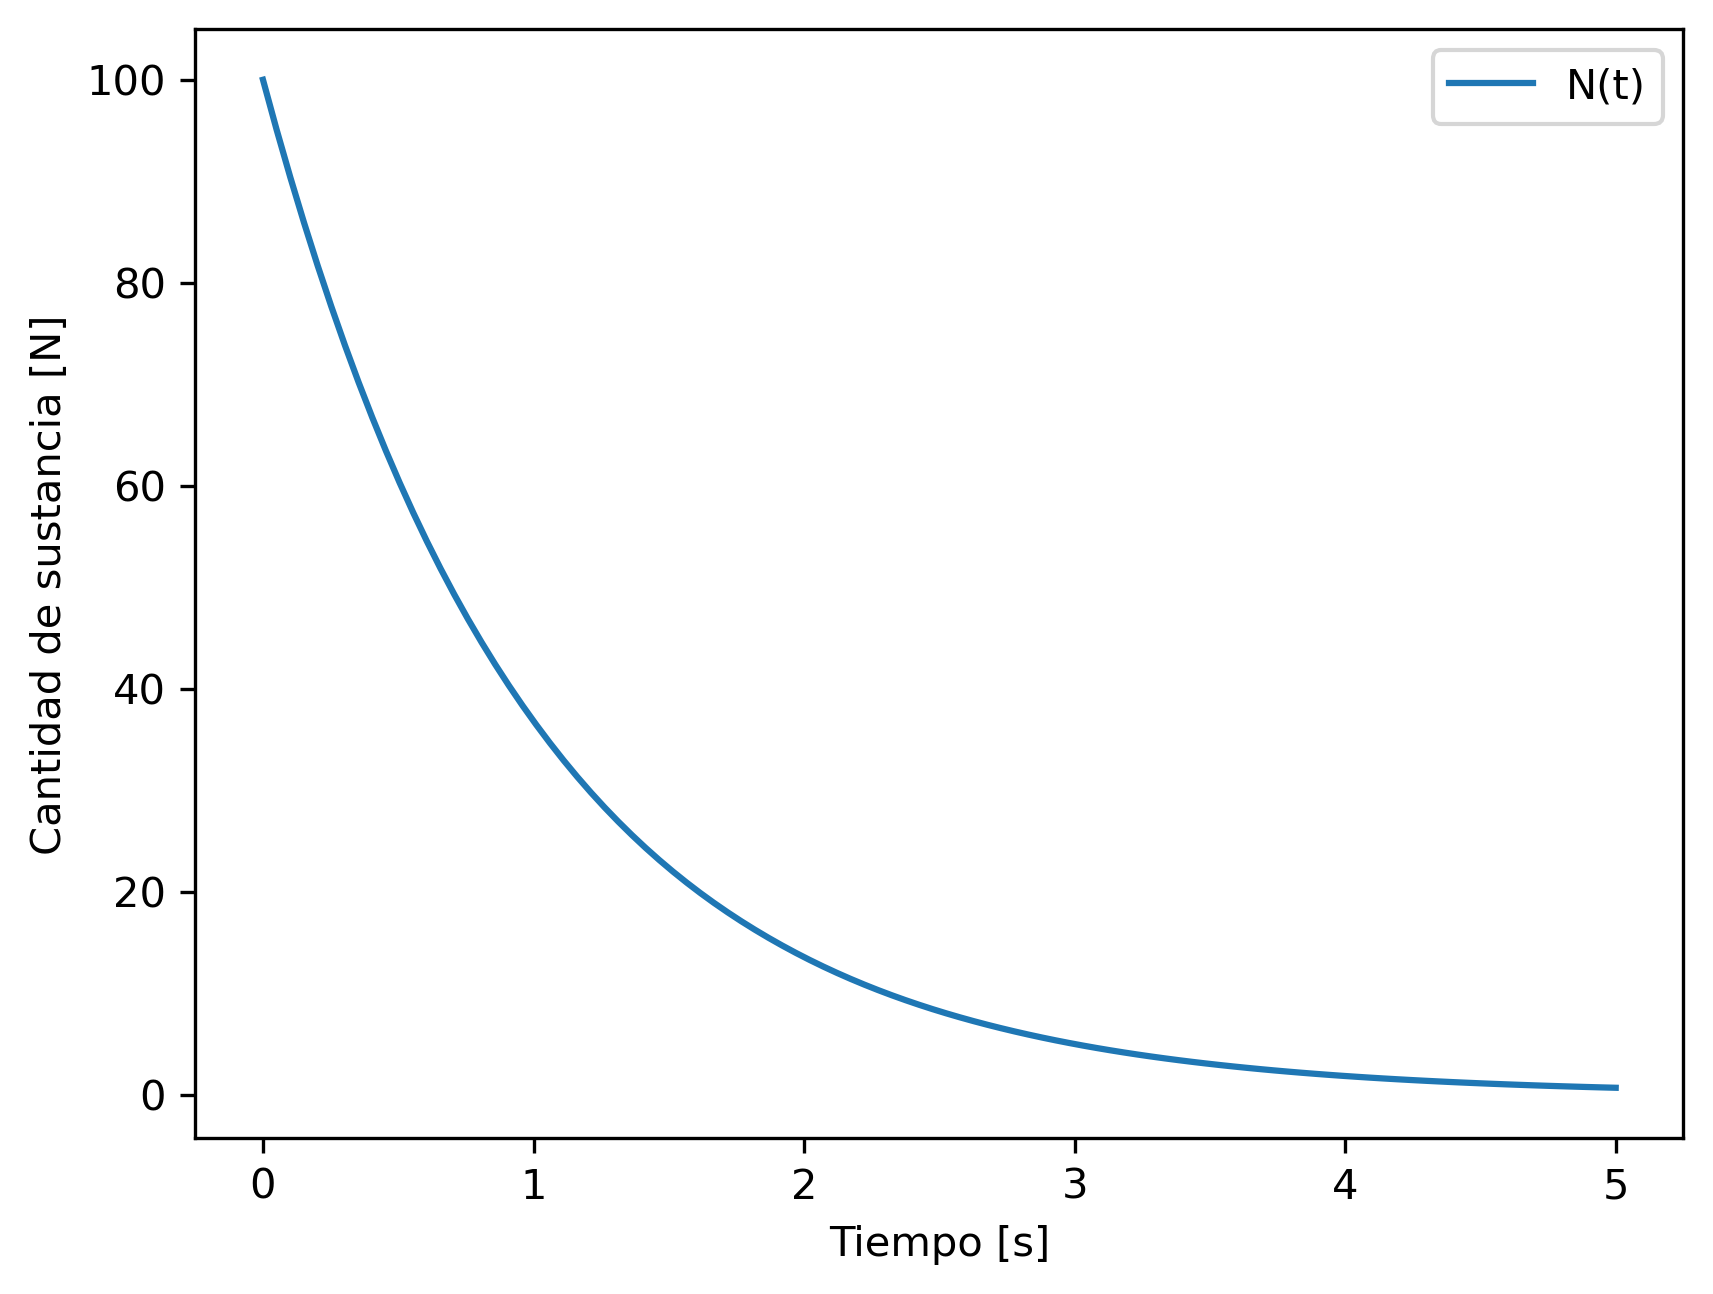

In [13]:
## grafico
fig = plt.figure(dpi = 300)
plt.plot(sol.t, sol.y[0], label='N(t)') # grafico de N(t)
plt.xlabel('Tiempo [s]') # etiqueta del eje X
plt.ylabel('Cantidad de sustancia [N]') # etiqueta del eje Y
plt.legend() # mostrar leyenda
plt.savefig('data_plots/edo.png') # guardar grafico
plt.show() # mostrar grafico

# Ejercicio 1

A partir de la reacción:
\begin{equation}
    \text{A} \to \text{C}
\end{equation}
Se le menciona que la evolución de A y C en el tiempo siguen la siguiente EDO:
\begin{equation}
    -\frac{dC_A}{dt} = \frac{dC_C}{dt} = 0.5 C_A^2
\end{equation}

Donde la concentración inicial de A es $C_A(t=0)= 1[M]$ y de C es $C_C(t=0)= 0[M]$ . Resuelva la EDO entre 0 [$min$] y 10 [$min$]. 

In [6]:
# paso 1
def edo1(t, C):
    ca, cc = C # en este caso C es un vector con dos componentes: ca y cc
    dca_dt = - 0.5 * ca**(2) 
    dcc_dt = 0.5 * ca**(2)
    return [dca_dt, dcc_dt] # se retornan las derivadas como una lista

# paso 2
t_span = [0, 10] # limites de integracion [min]
C0 = [1.0, 0.0] # condiciones iniciales: ca(0) = 1.0, cc(0) = 0.0
t_eval = np.linspace(0, 10, 100) # 100 puntos equiespaciados
# paso 3
sol = sp.integrate.solve_ivp(edo1, t_span, C0, t_eval=t_eval)


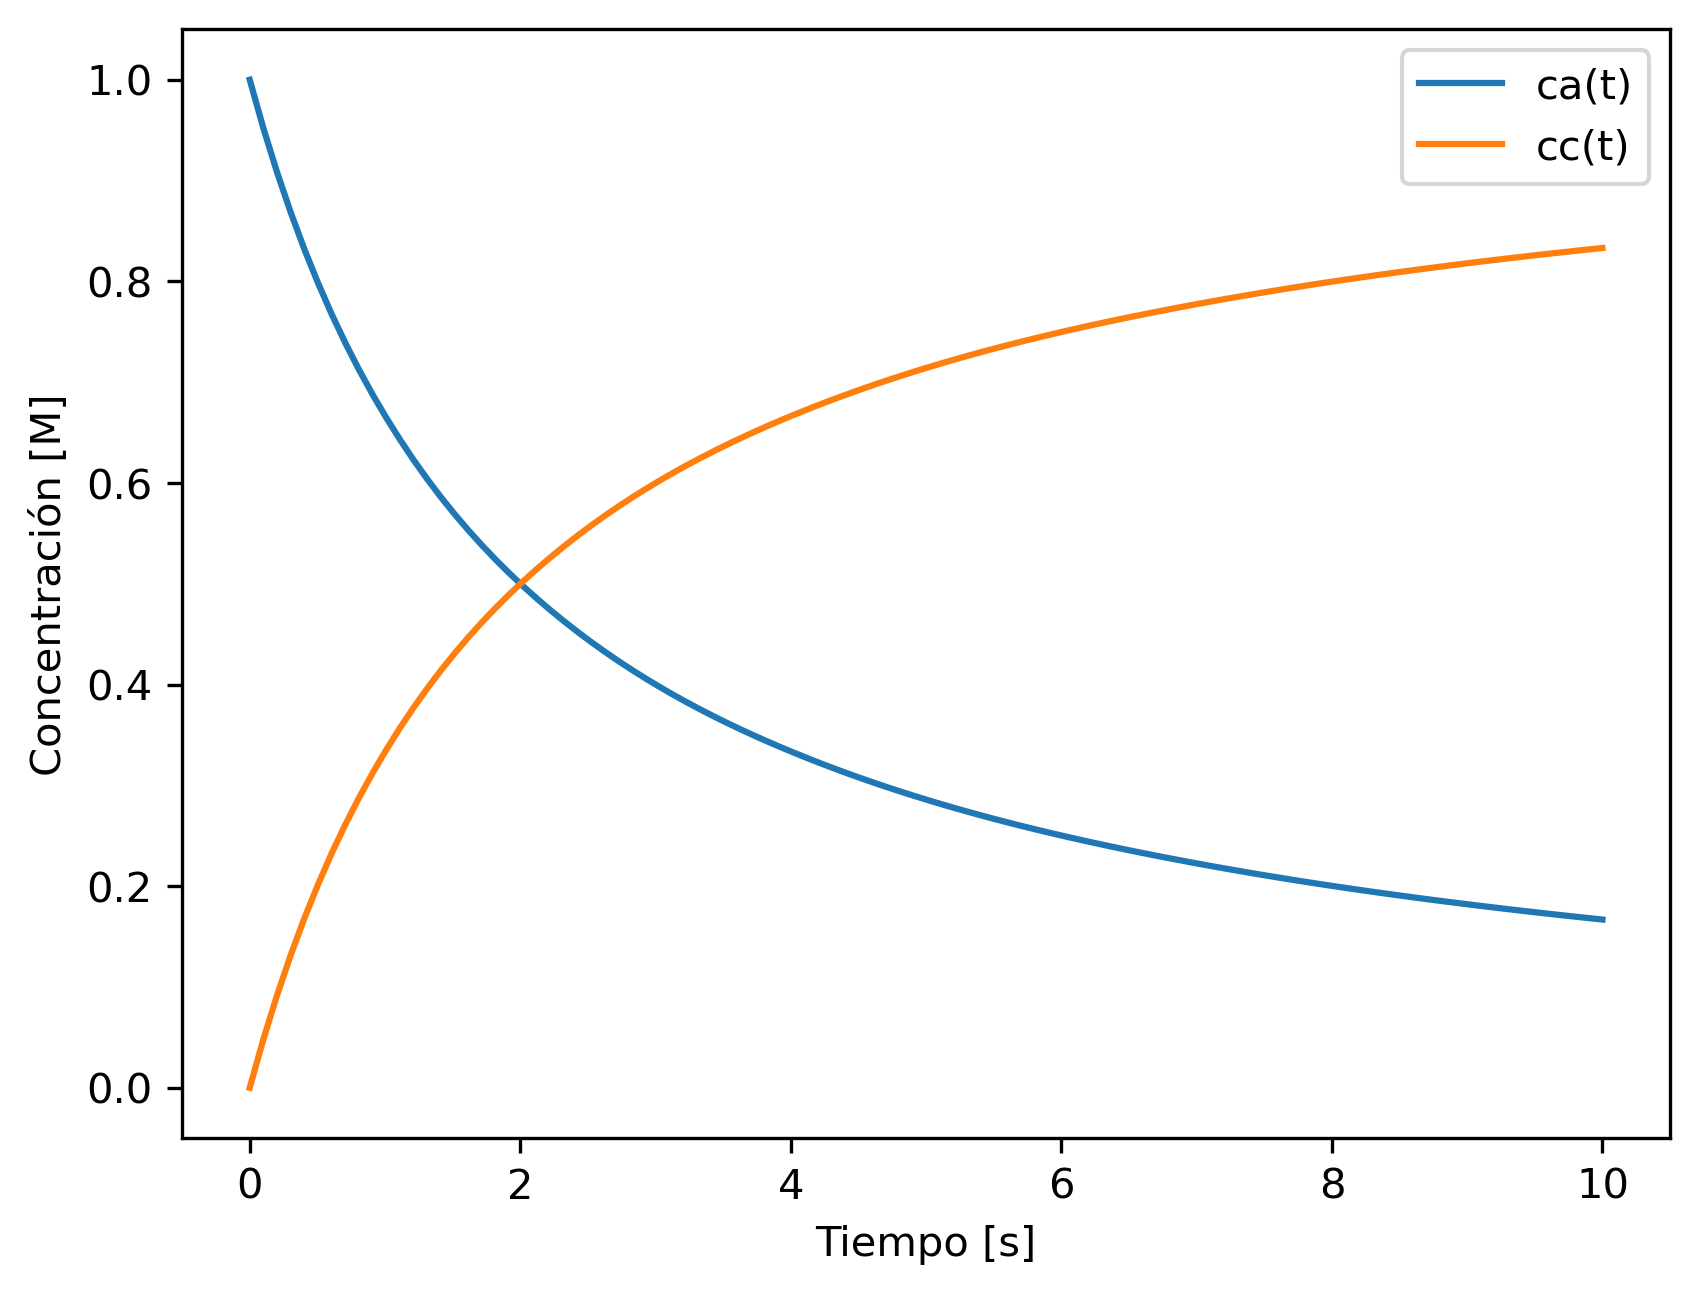

In [7]:
# grafico
fig = plt.figure(dpi = 300)
plt.plot(sol.t, sol.y[0], label='ca(t)') # grafico de ca(t)
plt.plot(sol.t, sol.y[1], label='cc(t)') # grafico de cc(t)
plt.xlabel('Tiempo [s]') # etiqueta del eje X
plt.ylabel('Concentración [M]') # etiqueta del eje Y
plt.legend() # mostrar leyenda
plt.show()

# Desafío

A partir de la reacción:
\begin{align}
            \text{A} + \text{B} \to \text{C}
\end{align}
Tiene que la evolución de A, B y C viene dada por:
\begin{align}
    -\frac{dC_A}{dt} = -\frac{dC_B}{dt} = \frac{dC_C}{dt} = k_1 \frac{C_A}{1+k_2\cdot C_A^2}C_B
\end{align}
Grafique la evolución entre 0 [$min$] y 10 [$min$] de las 3 especies considerando $C_A(t=0) =1 [M], C_B(t=0)=2[M]$ y $C_C(t=0) =0 [M]$, $k1 = 0.4$ y $k2 = 0.1$.

In [8]:
# paso 1
def ode_desafio(t, C, k1, k2):
    ca, cb, cc = C
    dca_dt = -k1 * (ca * (1+k2*ca**2)) * cb
    dcb_dt = -k1 * (ca * (1+k2*ca**2)) * cb
    dcc_dt = k1 * (ca * (1+k2*ca**2)) * cb
    return [dca_dt, dcb_dt, dcc_dt]

# paso 2
t_span = [0, 10] # limites de integracion [min]
C0 = [1.0, 2.0, 0.0] # condiciones iniciales: ca(0) = 1.0, cb(0) = 3.0, cc(0) = 0.0
t_eval = np.linspace(0, 10, 100) # 100 puntos equiespaciados
ks = [0.4, 0.1] # valores de k1 y k2

# paso 3
sol = sp.integrate.solve_ivp(ode_desafio, t_span, C0, t_eval=t_eval, args=(ks[0], ks[1]),)

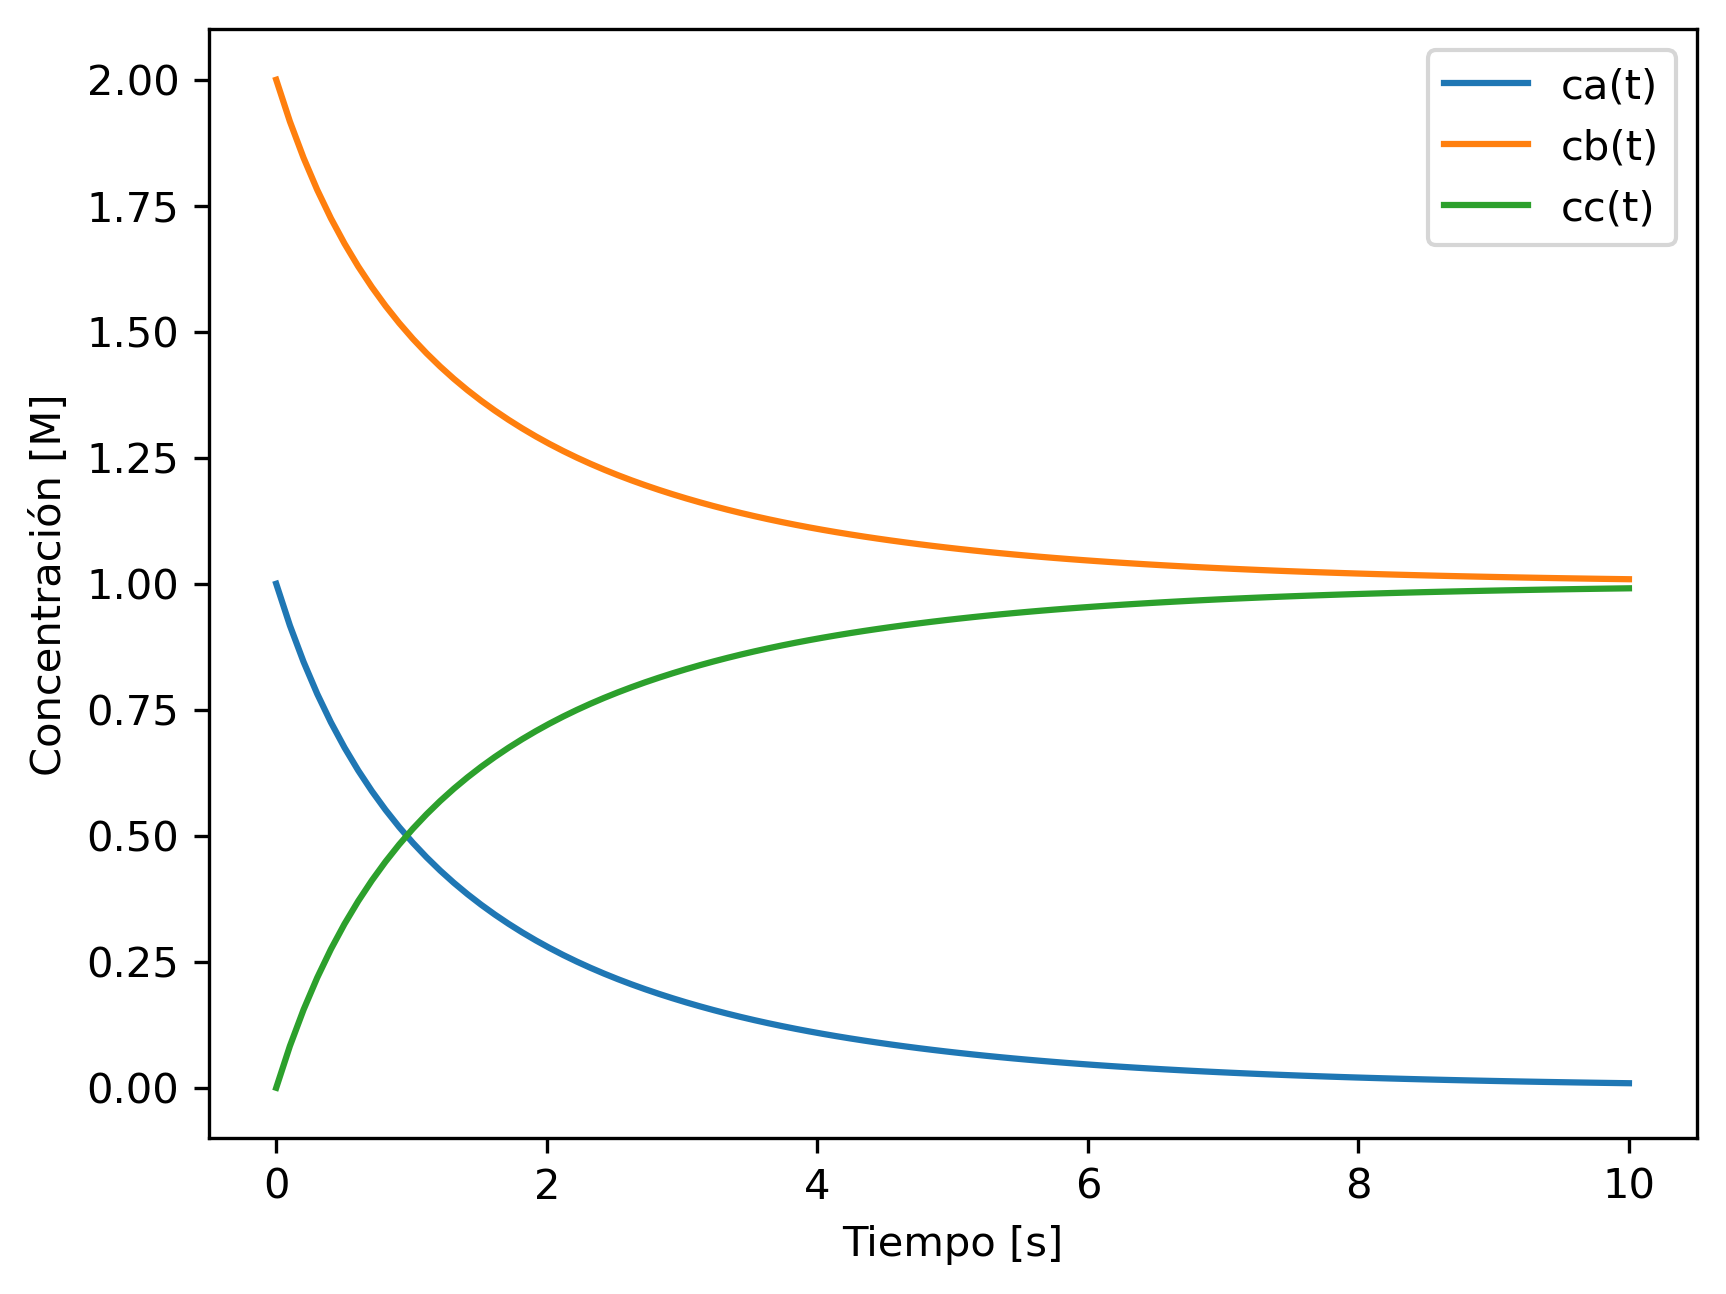

In [9]:
# grafico
fig = plt.figure(dpi = 300)
plt.plot(sol.t, sol.y[0], label='ca(t)') # grafico de ca(t)
plt.plot(sol.t, sol.y[1], label='cb(t)') # grafico de cb(t)
plt.plot(sol.t, sol.y[2], label='cc(t)') # grafico de cc(t)
plt.xlabel('Tiempo [s]') # etiqueta del eje X
plt.ylabel('Concentración [M]') # etiqueta del eje Y
plt.legend() # mostrar leyenda
plt.show() # mostrar grafico